<a href="https://colab.research.google.com/github/VahidehRajaei/Machine-Learning-Pipeline/blob/main/lastmlfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import gzip
import os
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC,LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# -------------------------------------------------------------------------
# STEP 1: Downloading the Dataset and Selecting 100,000 Samples
# -------------------------------------------------------------------------
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz"
filename = "HIGGS.csv.gz"

if not os.path.exists(filename):
    print("Downloading the HIGGS dataset...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")

print("100,000 random samples are being loaded from the dataset...")
chunks = []
with gzip.open(filename, 'rt') as f:
    for chunk in pd.read_csv(f, header=None, chunksize=500000):
        sampled_chunk = chunk.sample(frac=0.01, random_state=RANDOM_STATE)
        chunks.append(sampled_chunk)

df = pd.concat(chunks, axis=0).sample(n=100000, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Data size: {df.shape}")


y = df.iloc[:, 0].astype(int)
X = df.iloc[:, 1:]
X.columns = [f"Feature_{i}" for i in range(1, 29)]

# -------------------------------------------------------------------------
# STEP 2: Data Exploration
# -------------------------------------------------------------------------

print("\nThe first 5 lines of the properties:\n")
print(X.head())

print("\nNumber of missing data in each column:\n")
null_control = X.isnull().sum()
print(null_control)

print(f"\nTotal Number of Missing Data: {null_control.sum()}")

Download complete.
100,000 random samples are being loaded from the dataset...
Data size: (100000, 29)

The first 5 lines of the properties:

   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0   0.635774  -1.062654   1.251074   1.431667   0.561306   0.839855   
1   2.578781   0.488878  -1.333575   0.705771   1.695338   1.076660   
2   1.319496  -0.187056  -1.386287   0.833538   1.326575   2.010504   
3   0.880091  -0.256208  -1.368532   1.344133   1.077844   0.662687   
4   1.102447   1.627448   1.458037   0.984657   0.476618   0.790570   

   Feature_7  Feature_8  Feature_9  Feature_10  ...  Feature_19  Feature_20  \
0   0.402998  -0.787157   2.173076    0.722182  ...    0.716600    0.531999   
1   0.291102   0.275685   2.173076    0.593761  ...    0.778229    0.546427   
2   0.600054  -0.149623   1.086538    1.248459  ...    0.193587    1.347720   
3   0.008887   0.139309   2.173076    1.209933  ...    0.264377   -0.997999   
4   0.963468  -1.027756   1.086538  

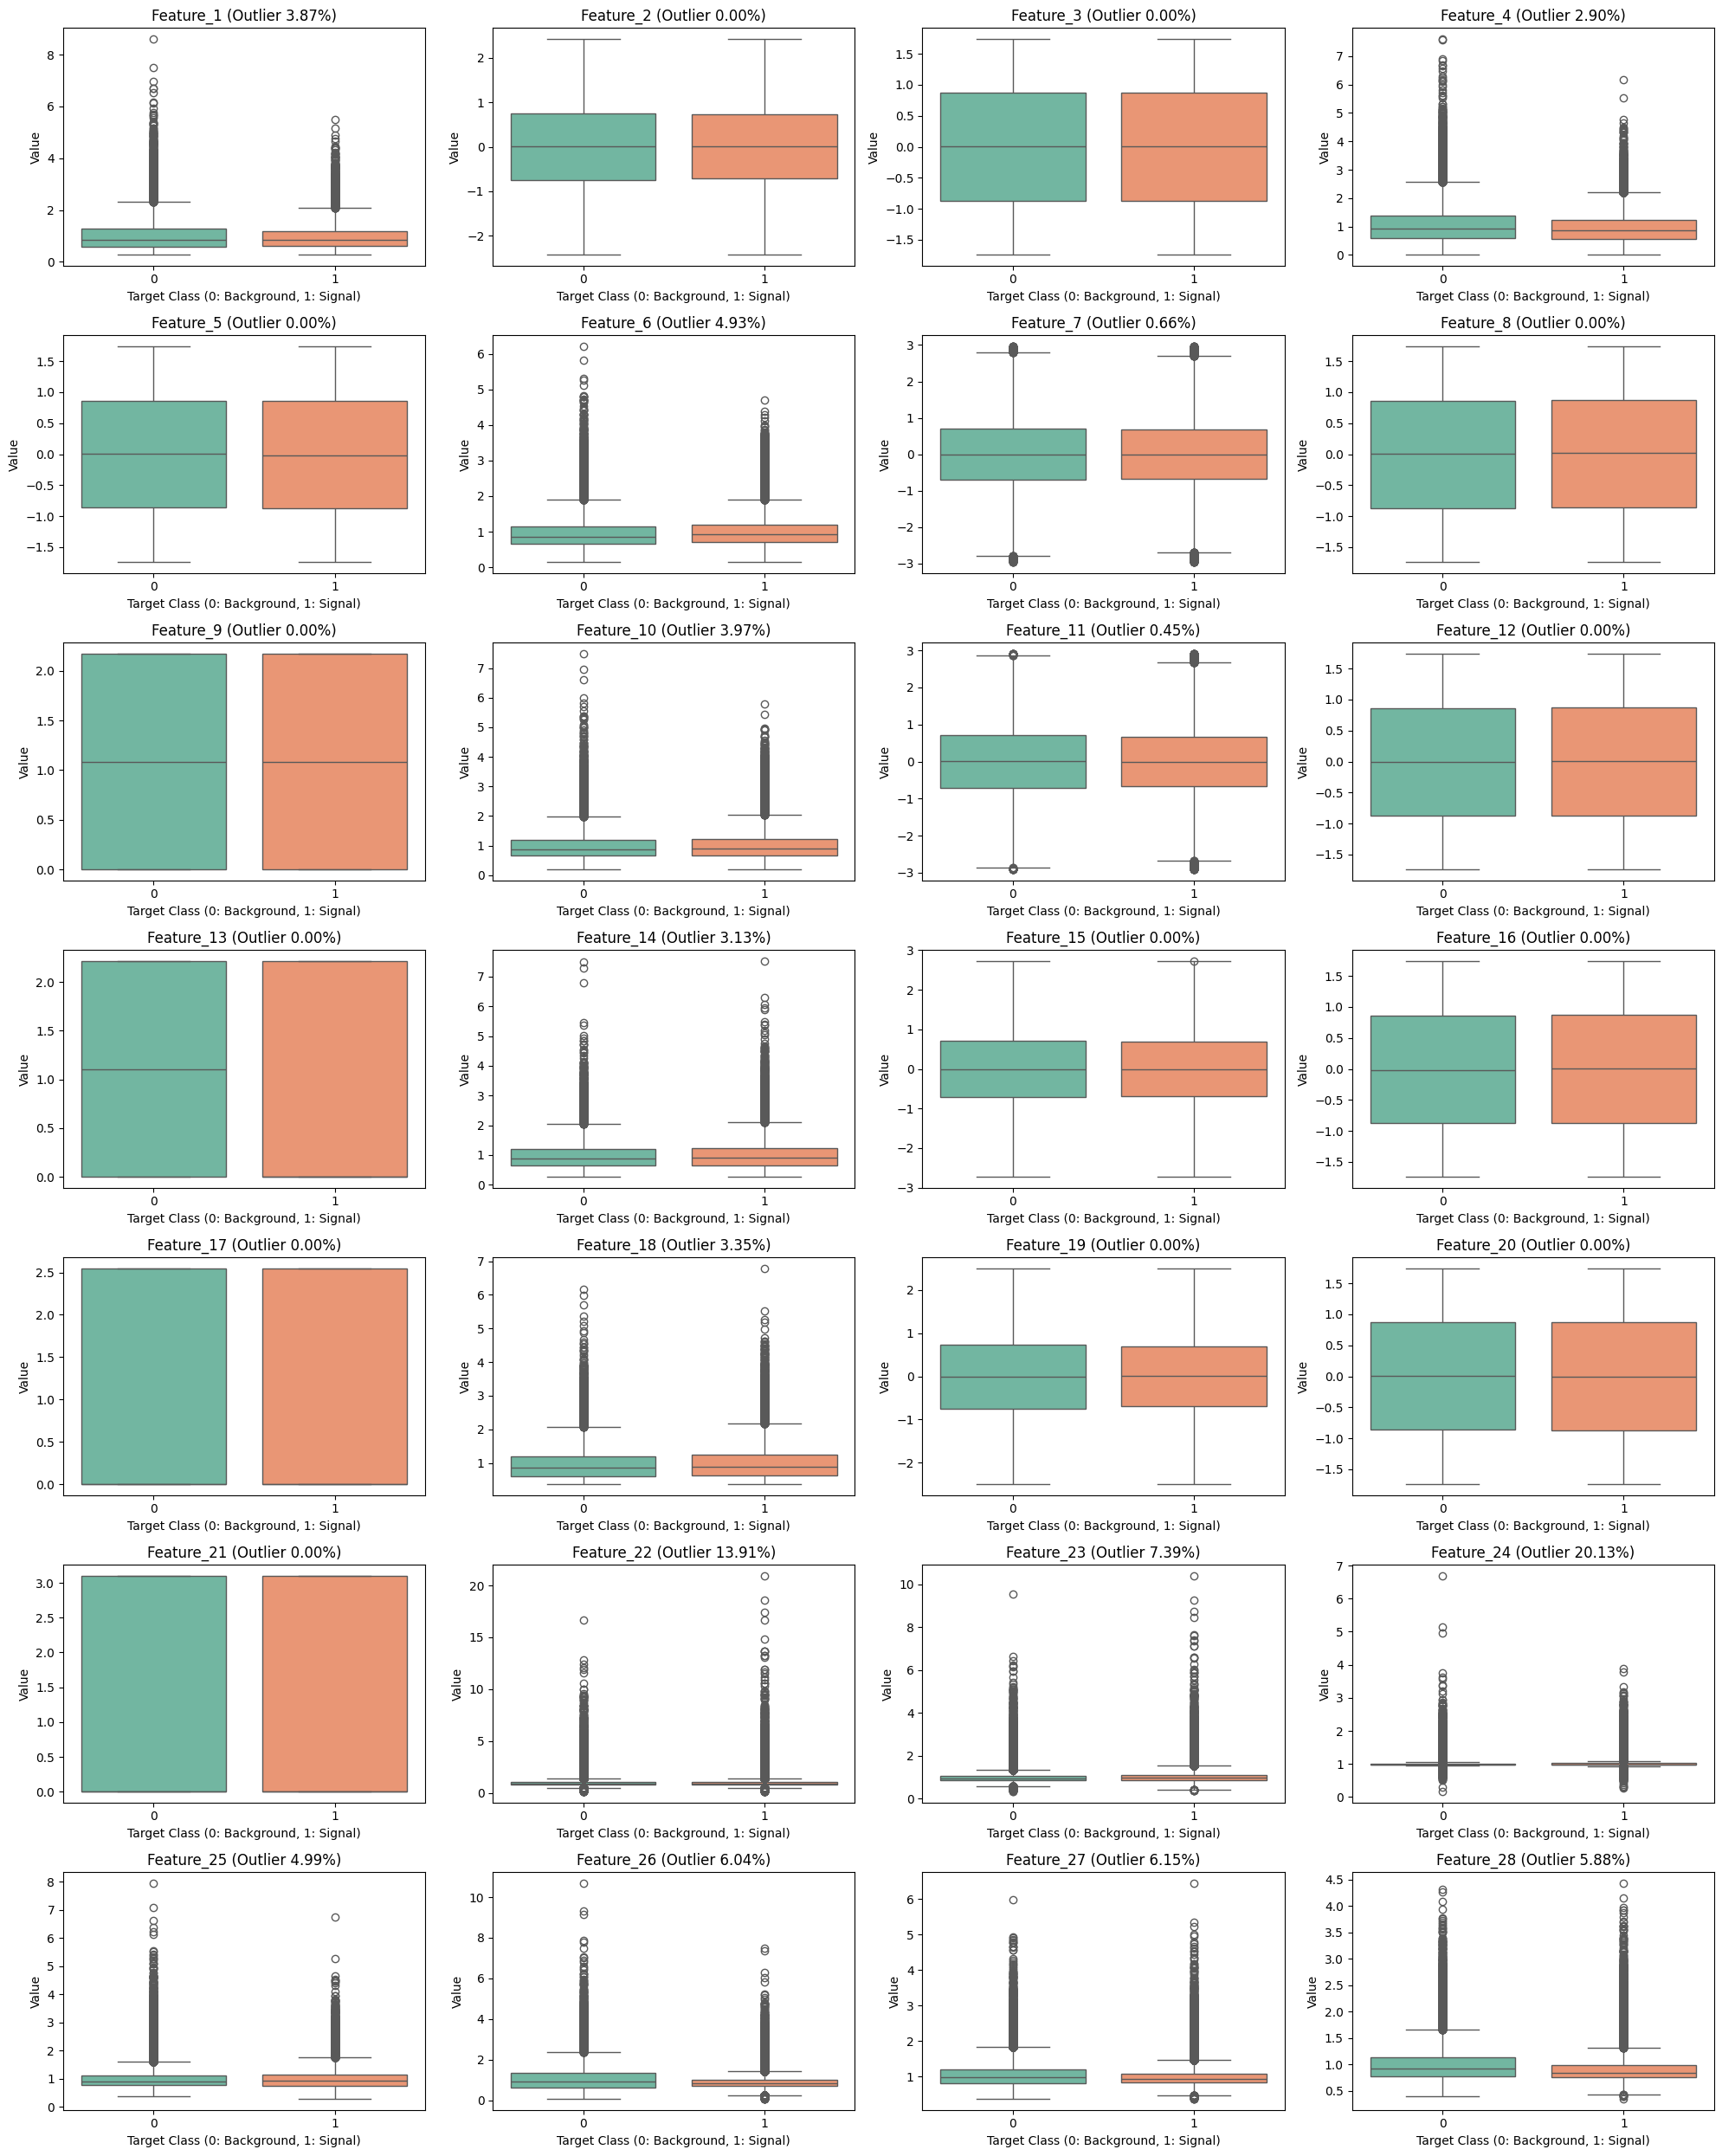

In [ ]:
# -------------------------------------------------------------------------
# STEP 3: Exploratory Data Analysis (EDA)
# -------------------------------------------------------------------------

outlier_percentages = []
fig, axes = plt.subplots(7, 4, figsize=(20, 25))
axes = axes.flatten()

for idx, col in enumerate(X.columns):
    # 1. IQR Calculation (To find the percentage of outliers across all data)
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
    pct_outlier = (len(outliers) / len(X)) * 100
    outlier_percentages.append({'Feature': col, 'Outlier Value (%)': f"{pct_outlier:.2f}%"})

    # 2. Box Plot Drawing Decomposed by Target Class
    sns.boxplot(x=y, y=X[col], ax=axes[idx], palette="Set2")
    axes[idx].set_title(f"{col} (Outlier {pct_outlier:.2f}%)")
    axes[idx].set_xlabel("Target Class (0: Background, 1: Signal)")
    axes[idx].set_ylabel("Value")

plt.tight_layout()
plt.savefig('features_target_boxplots.png', dpi=300)
plt.show()

In [ ]:
# -------------------------------------------------------------------------
# STEP 4 (Bölüm 1): Data Preprocessing
# -------------------------------------------------------------------------
# 1. Outlier Analysis (Winsorization) with IQR Method
for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X[col] = np.where(X[col] < lower_bound, lower_bound, X[col])
    X[col] = np.where(X[col] > upper_bound, upper_bound, X[col])

# 2. Feature Scaling (MinMaxScaler)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

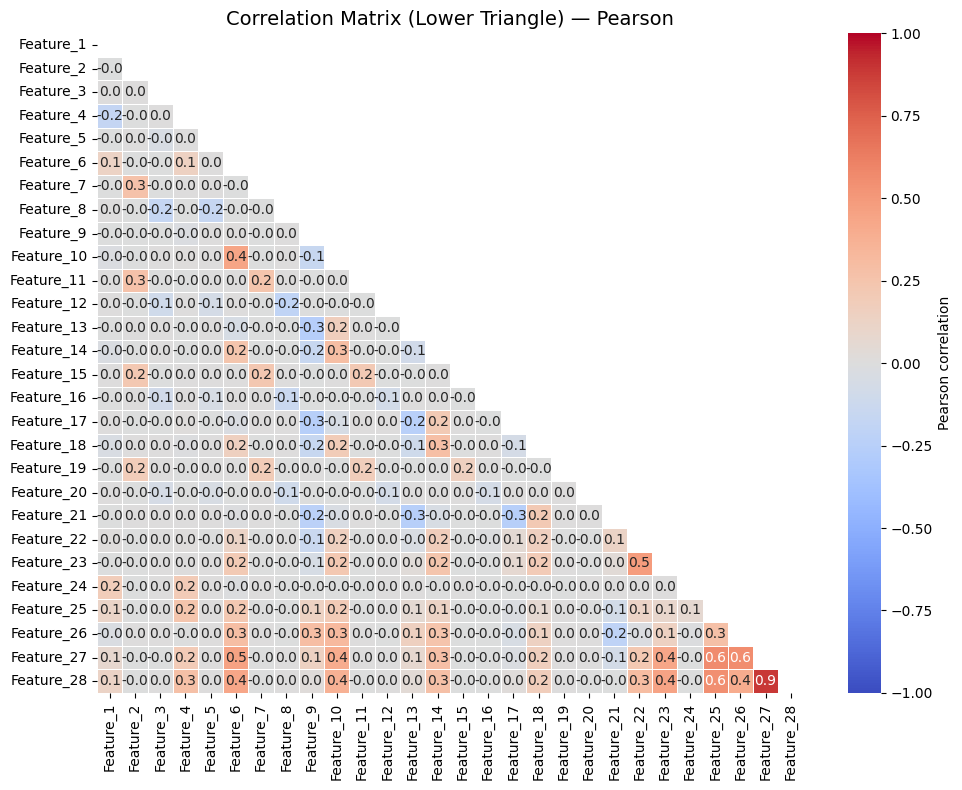

In [ ]:
# -------------------------------------------------------------------------
# Correlation Matrix
# -------------------------------------------------------------------------
def plot_corr_lower_pearson(df):

    # Calculate correlation
    corr = df.corr(method='pearson')

    # Mask to hide upper triangle :The upper triangle and the lower triangle both have exactly the same information.
    mask = np.triu(np.ones_like(corr, dtype=bool))


    plt.figure(figsize=(10, 8))
    sns.heatmap(corr,
                mask=mask,
                annot=True,
                fmt=".1f",
                cmap='coolwarm',
                vmin=-1, vmax=1,
                linewidths=0.5,
                cbar_kws={'label': 'Pearson correlation'})

    plt.title('Correlation Matrix (Lower Triangle) — Pearson', fontsize=14)
    plt.tight_layout()
    plt.show()

# ---  FUNCTION CALL ---
plot_corr_lower_pearson(X)

In [ ]:
# -------------------------------------------------------------------------
# STEP 5 (Bölüm 2 & 3): Feature Selection and Quick Nested Cross-Validation
# -------------------------------------------------------------------------

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

models_config = {
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, n_estimators=50),
        'params': {
            'max_depth': [3, 5],
            'learning_rate': [0.1, 0.2]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(n_jobs=-1),
        'params': {
            'n_neighbors': [3, 7, 11]
        }
    },
    'MLP': {
        'model': MLPClassifier(max_iter=100, early_stopping=True, random_state=RANDOM_STATE),
        'params': {
            'hidden_layer_sizes': [(50,), (100,)],
            'activation': ['relu', 'tanh']
        }
    },
    'SVM': {
        'model': CalibratedClassifierCV(LinearSVC(dual=False, random_state=RANDOM_STATE)),
        'params': {
            'estimator__C': [0.1, 1, 10],
            # 'kernel': ['linear', 'rbf']
        }
    }
}

results = {model_name: {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'y_real': [], 'y_proba': []}
           for model_name in models_config.keys()}

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_scaled, y), 1):
    print(f"Executing Outer Fold {fold}/5...")

    X_train_fold, X_test_fold = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    # Top 15 Feature Selections with ANOVA F-score (Flowchart A)
    selector = SelectKBest(score_func=f_classif, k=15)
    X_train_selected = selector.fit_transform(X_train_fold, y_train_fold)
    X_test_selected = selector.transform(X_test_fold)

    for model_name, config in models_config.items():
        # Inner Loop Flowchart B
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=inner_cv,
            scoring='roc_auc',
            n_jobs=-1 # Force all CPU cores
        )

        grid_search.fit(X_train_selected, y_train_fold)
        best_model = grid_search.best_estimator_

        y_pred = best_model.predict(X_test_selected)
        y_proba = best_model.predict_proba(X_test_selected)[:, 1]

        results[model_name]['accuracy'].append(accuracy_score(y_test_fold, y_pred))
        results[model_name]['precision'].append(precision_score(y_test_fold, y_pred))
        results[model_name]['recall'].append(recall_score(y_test_fold, y_pred))
        results[model_name]['f1'].append(f1_score(y_test_fold, y_pred))

        results[model_name]['y_real'].extend(y_test_fold)
        results[model_name]['y_proba'].extend(y_proba)

Executing Outer Fold 1/5...
Executing Outer Fold 2/5...
Executing Outer Fold 3/5...
Executing Outer Fold 4/5...
Executing Outer Fold 5/5...


		==== Final Performance Metrics Table ====

  Model Accuracy Precision Recall F1 Score ROC-AUC
XGBoost   0.7154    0.7298 0.7375   0.7336  0.7918
    KNN   0.6695    0.6737 0.7330   0.7021  0.7260
    MLP   0.7135    0.7337 0.7241   0.7286  0.7828
    SVM   0.6431    0.6429 0.7384   0.6874  0.6808



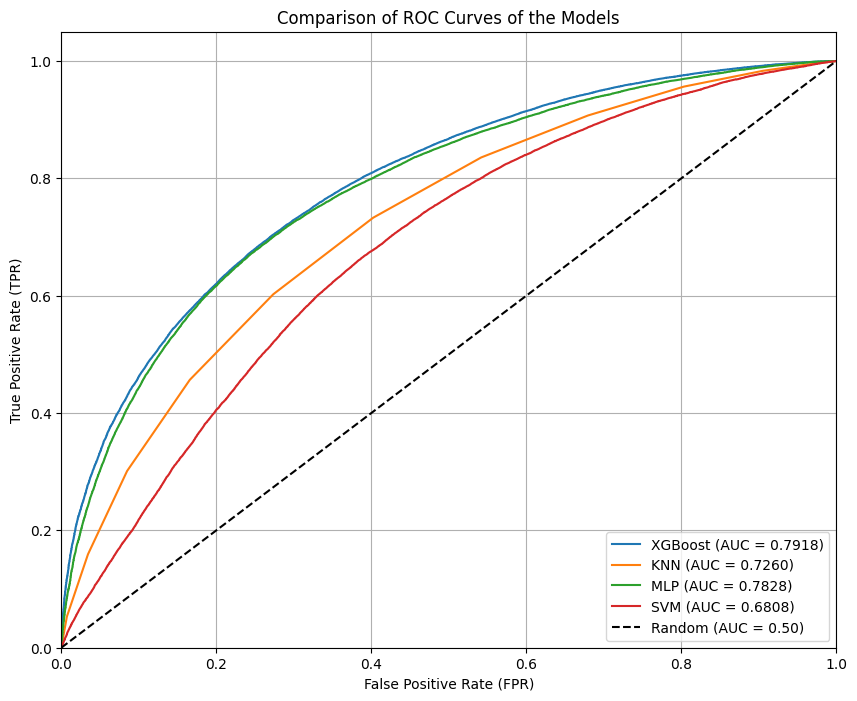

In [ ]:
# -------------------------------------------------------------------------
# STEP 6: View the results of Bölüm 3
# -------------------------------------------------------------------------
summary_data = []
plt.figure(figsize=(10, 8))

for model_name in results.keys():
    mean_acc = np.mean(results[model_name]['accuracy'])
    mean_prec = np.mean(results[model_name]['precision'])
    mean_rec = np.mean(results[model_name]['recall'])
    mean_f1 = np.mean(results[model_name]['f1'])

    fpr, tpr, _ = roc_curve(results[model_name]['y_real'], results[model_name]['y_proba'])
    roc_auc = auc(fpr, tpr)

    summary_data.append({
        'Model': model_name,
        'Accuracy': f"{mean_acc:.4f}",
        'Precision': f"{mean_prec:.4f}",
        'Recall': f"{mean_rec:.4f}",
        'F1 Score': f"{mean_f1:.4f}",
        'ROC-AUC': f"{roc_auc:.4f}"
    })

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")

df_summary = pd.DataFrame(summary_data)
print("\t\t==== Final Performance Metrics Table ====\n")
print(f"{df_summary.to_string(index=False)}\n")

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Comparison of ROC Curves of the Models')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('models_roc_curves.png', dpi=300)
plt.show()